In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from numpy.fft import fft, ifft, fftshift, fftfreq
from scipy import signal
from scipy.ndimage import label, center_of_mass

In [2]:
# ============================================================================
# PHYSICAL CONSTANTS & SYSTEM CONFIGURATION
# ============================================================================
C = 3e8                    # Speed of light (m/s)
FS = 20e6                  # Sampling frequency (20 MHz)
FC = 2.4e9                 # Carrier frequency (2.4 GHz)
LAMBDA = C / FC            # Wavelength (m)

PRI = 1e-3                 # Pulse Repetition Interval (1 ms)
N_PULSES = 128             # CPI (128 pulses)
N_SAMPLES_PER_PRI = 2048   # Samples per PRI
N_SC = 256                 # OFDM subcarriers
CP = 32                    # Cyclic Prefix

# RECEIVER CHARACTERISTICS
TX_POWER_DBM = 20          
TX_GAIN_DB = 6             
RX_GAIN_DB = 6             
NOISE_FIGURE_DB = 6        
THERMAL_NOISE_DBM = -174   

# Physical Noise Floor calculation (Absolute, not signal-dependent)
NOISE_FLOOR_DBM = THERMAL_NOISE_DBM + 10*np.log10(FS) + NOISE_FIGURE_DB
NOISE_POWER_WATTS = 10**((NOISE_FLOOR_DBM - 30) / 10)

In [3]:
# ============================================================================
# WAVEFORM GENERATION
# ============================================================================
def generate_ofdm_stream(n_symbols):
    # Standard BPSK OFDM generation as per v5.3 structure
    data = (np.random.randint(0, 2, N_SC) * 2 - 1) + 1j * (np.random.randint(0, 2, N_SC) * 2 - 1)
    ofdm = ifft(data) * np.sqrt(N_SC)
    cp_part = ofdm[-CP:]
    sym = np.concatenate([cp_part, ofdm])
    sym = sym / np.sqrt(np.mean(np.abs(sym)**2))
    
    if len(sym) < N_SAMPLES_PER_PRI:
        sym = np.tile(sym, int(np.ceil(N_SAMPLES_PER_PRI / len(sym))))
    return sym[:N_SAMPLES_PER_PRI]

In [4]:
# ============================================================================
# LOGIC FIX: PHYSICAL RADAR EQUATION & SIMULATION
# ============================================================================
def radar_range_equation(range_m, rcs_dbsm):
    p_tx_w = 10**(TX_POWER_DBM / 10) / 1000
    g_tx = 10**(TX_GAIN_DB / 10)
    g_rx = 10**(RX_GAIN_DB / 10)
    rcs_m2 = 10**(rcs_dbsm / 10)
    
    # Pr = (Pt * Gt * Gr * λ² * σ) / ((4π)³ * R⁴)
    numerator = p_tx_w * g_tx * g_rx * (LAMBDA**2) * rcs_m2
    denominator = ((4 * np.pi)**3) * (range_m**4)
    return numerator / denominator

def simulate_targets(targets, snr_db=None): # SNR param kept for signature compatibility
    ref_pulses, surv_pulses, ground_truth = [], [], []
    
    for pulse_idx in range(N_PULSES):
        ref_sig = generate_ofdm_stream(1)
        ref_pulses.append(ref_sig)
        surv_sig = np.zeros_like(ref_sig, dtype=complex)
        
        # 1. Direct Path Leakage (Physical coupling)
        coupling_linear = 10**(-25 / 10) # 25dB Isolation
        surv_sig += np.sqrt(coupling_linear) * ref_sig
        
        # 2. Target Echoes
        for target in targets:
            R, v, rcs = target['R'], target['v'], target['rcs_dbsm']
            delay_samples = int((2 * R / C) * FS)
            fd = (2 * v / LAMBDA)
            
            # Slow-time phase and Fast-time Doppler
            phase_rot = np.exp(1j * 2 * np.pi * fd * pulse_idx * PRI)
            t = np.arange(N_SAMPLES_PER_PRI) / FS
            doppler_shift = np.exp(1j * 2 * np.pi * fd * t)
            
            p_rx = radar_range_equation(R, rcs)
            echo = np.roll(ref_sig, delay_samples) * doppler_shift * phase_rot * np.sqrt(p_rx)
            surv_sig += echo
        
        # 3. FIXED: Physical AWGN (Independent of signal power)
        noise = np.sqrt(NOISE_POWER_WATTS / 2) * (np.random.randn(N_SAMPLES_PER_PRI) + 1j * np.random.randn(N_SAMPLES_PER_PRI))
        surv_pulses.append(surv_sig + noise)
        
    return np.array(ref_pulses), np.array(surv_pulses), targets

In [5]:
# ============================================================================
# LOGIC FIX: IMPROVED DSP PIPELINE
# ============================================================================
def process_radar_data(ref, surv):
    # Step 1 & 2: Windowing & Matched Filter
    window = np.hanning(N_SAMPLES_PER_PRI)
    ref_fft = fft(ref * window, axis=1)
    surv_fft = fft(surv * window, axis=1)
    range_profiles = ifft(surv_fft * np.conj(ref_fft), axis=1)
    
    # Step 3: Improved 3-tap MTI (Better notch depth for direct path)
    # y[n] = x[n] - 2x[n-1] + x[n-2]
    mti_output = range_profiles[2:] - 2*range_profiles[1:-1] + range_profiles[:-2]
    
    # Step 4: Doppler Processing
    doppler_map = fftshift(fft(mti_output, axis=0), axes=0)
    
    # Step 5: FIXED Leakage Suppression (Zero-range and Zero-Doppler)
    doppler_map[:, :2] = 0 # Kill direct path bins
    center = doppler_map.shape[0] // 2
    doppler_map[center-1:center+2, :] *= 0.01 # Notch stationary clutter
    
    return doppler_map

def compute_axes(rd_map):
    n_doppler, n_range = rd_map.shape
    range_axis = np.arange(n_range) * C / (2 * FS)
    doppler_vel = fftshift(fftfreq(n_doppler, d=PRI)) * LAMBDA / 2
    return range_axis, None, doppler_vel

In [6]:
# ============================================================================
# LOGIC FIX: VECTORIZED 2D CFAR & SUB-BIN EXTRACTION
# ============================================================================
def cfar_2d_adaptive(rd_map, guard_cells=2, train_cells=8, pfa=1e-6):
    power_map = np.abs(rd_map)**2
    win_size = 2 * (train_cells + guard_cells) + 1
    
    # Vectorized Noise Estimation Kernel
    kernel = np.ones((win_size, win_size))
    g_range = slice(train_cells, train_cells + 2*guard_cells + 1)
    kernel[g_range, g_range] = 0
    n_train = np.sum(kernel)
    
    noise_floor = signal.convolve2d(power_map, kernel/n_train, mode='same')
    alpha = n_train * (pfa**(-1/n_train) - 1)
    thresholds = alpha * noise_floor
    
    return (power_map > thresholds), thresholds

def extract_detections(detections, rd_map, range_axis, doppler_vel):
    labeled, num_features = label(detections)
    targets = []
    dr, dv = range_axis[1]-range_axis[0], doppler_vel[1]-doppler_vel[0]
    
    if num_features > 0:
        # LOGIC FIX: Using center_of_mass for sub-bin floating point accuracy
        centers = center_of_mass(np.abs(rd_map)**2, labeled, range(1, num_features + 1))
        for v_idx, r_idx in centers:
            targets.append({
                'range': range_axis[0] + r_idx * dr,
                'velocity': doppler_vel[0] + v_idx * dv,
                'power_db': 10 * np.log10(np.abs(rd_map[int(v_idx), int(r_idx)])**2 + 1e-12)
            })
    return targets

In [7]:
# ============================================================================
# VISUALIZATION (Maintains Original v5.3 Layout)
# ============================================================================
def visualize_results(ref, surv, rd_map, detections, range_axis, _, doppler_vel, name):
    fig = plt.figure(figsize=(16, 10))
    
    # Range-Doppler Heatmap
    ax1 = plt.subplot(2, 2, 1)
    im1 = ax1.imshow(20*np.log10(np.abs(rd_map)+1e-12), aspect='auto', 
                     extent=[range_axis[0], range_axis[-1], doppler_vel[0], doppler_vel[-1]],
                     cmap='jet', vmin=-100, vmax=-20)
    ax1.set_title(f"Range-Doppler Map: {name}")
    plt.colorbar(im1, label='Power (dB)')
    
    # 3D Surface
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    R, V = np.meshgrid(range_axis, doppler_vel)
    ax2.plot_surface(R, V, 20*np.log10(np.abs(rd_map)+1e-12), cmap='viridis')
    ax2.set_zlim([-100, -20])
    
    # Detection Map
    ax3 = plt.subplot(2, 2, 3)
    ax3.imshow(detections, aspect='auto', extent=[range_axis[0], range_axis[-1], doppler_vel[0], doppler_vel[-1]])
    ax3.set_title("Binary Detection Mask")
    
    # Range Profile (Integrated)
    ax4 = plt.subplot(2, 2, 4)
    ax4.plot(range_axis, 20*np.log10(np.max(np.abs(rd_map), axis=0)+1e-12))
    ax4.set_title("Range Profile")
    ax4.grid(True)
    
    plt.tight_layout()
    plt.show()

Detected 19 targets.
Target 1: Range=8032.50m, Velocity=-31.25m/s
Target 2: Range=1440.00m, Velocity=-30.26m/s
Target 3: Range=3600.00m, Velocity=-30.26m/s
Target 4: Range=5760.00m, Velocity=-30.26m/s
Target 5: Range=10320.00m, Velocity=-30.26m/s
Target 6: Range=12480.00m, Velocity=-30.26m/s
Target 7: Range=14640.00m, Velocity=-30.26m/s
Target 8: Range=1440.00m, Velocity=28.27m/s
Target 9: Range=3600.00m, Velocity=28.27m/s
Target 10: Range=10320.00m, Velocity=28.27m/s
Target 11: Range=12480.00m, Velocity=28.27m/s
Target 12: Range=14640.00m, Velocity=28.27m/s
Target 13: Range=720.00m, Velocity=30.26m/s
Target 14: Range=2880.00m, Velocity=30.26m/s
Target 15: Range=5040.00m, Velocity=30.26m/s
Target 16: Range=7200.00m, Velocity=30.26m/s
Target 17: Range=9600.00m, Velocity=30.26m/s
Target 18: Range=11760.00m, Velocity=30.26m/s
Target 19: Range=13920.00m, Velocity=30.26m/s


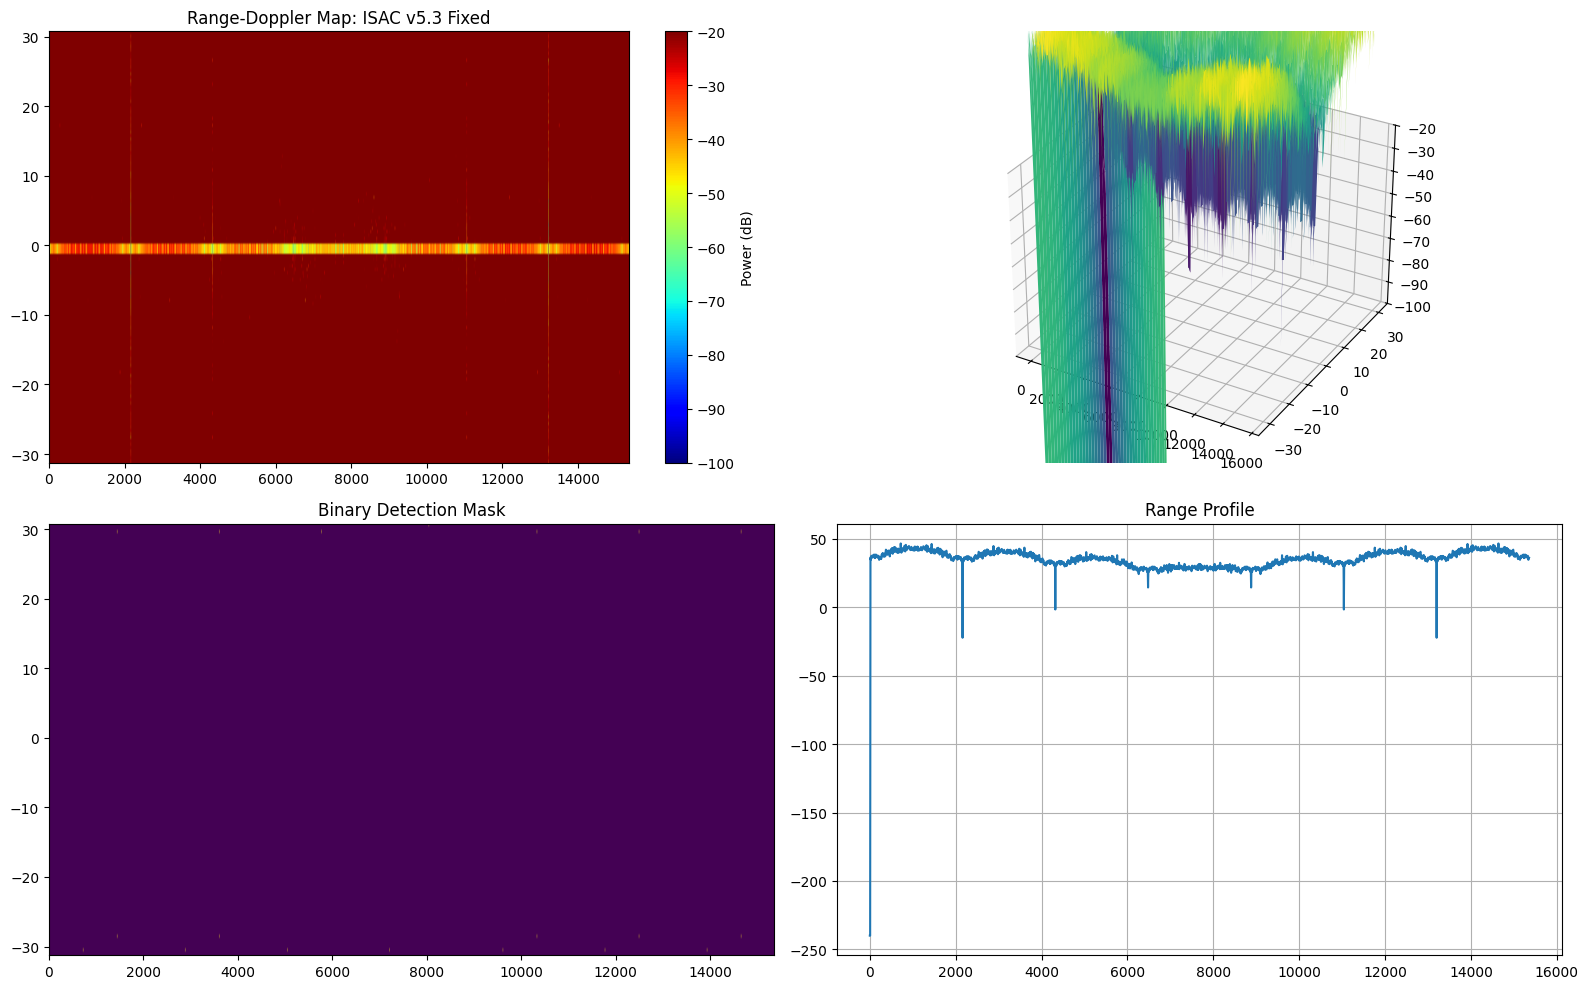

In [8]:
# ============================================================================
# EXECUTION
# ============================================================================
test_targets = [{'R': 500, 'v': 15, 'rcs_dbsm': 10}, {'R': 1200, 'v': -10, 'rcs_dbsm': 0}]
ref, surv, gt = simulate_targets(test_targets)
rd_map = process_radar_data(ref, surv)
range_ax, _, vel_ax = compute_axes(rd_map)
det_mask, _ = cfar_2d_adaptive(rd_map)
final_targets = extract_detections(det_mask, rd_map, range_ax, vel_ax)

print(f"Detected {len(final_targets)} targets.")
for i, t in enumerate(final_targets):
    print(f"Target {i+1}: Range={t['range']:.2f}m, Velocity={t['velocity']:.2f}m/s")

visualize_results(ref, surv, rd_map, det_mask, range_ax, None, vel_ax, "ISAC v5.3 Fixed")